In [1]:
%matplotlib inline

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

ds_, info = tfds.load(
    'tf_flowers',
    as_supervised=True,
    split=['train[:90%]', 'train[90%:]'],
    with_info=True
)
ds_train_, ds_valid_ = ds_

for (image, label) in ds_train_.take(5):
    print(image.shape, label)

print(info)

num_classes = info.features['label'].num_classes
print("Number of classes:", num_classes)

image_shape = info.features['image'].shape
print("Image shape:", image_shape)

2024-09-01 02:36:11.274033: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-09-01 02:36:11.372109: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-01 02:36:11.431971: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-01 02:36:11.443587: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-01 02:36:11.511242: I tensorflow/core/platform/cpu_feature_guar

(333, 500, 3) tf.Tensor(2, shape=(), dtype=int64)
(212, 320, 3) tf.Tensor(3, shape=(), dtype=int64)
(240, 320, 3) tf.Tensor(3, shape=(), dtype=int64)
(240, 320, 3) tf.Tensor(4, shape=(), dtype=int64)
(317, 500, 3) tf.Tensor(3, shape=(), dtype=int64)
tfds.core.DatasetInfo(
    name='tf_flowers',
    full_name='tf_flowers/3.0.1',
    description="""
    A large set of images of flowers
    """,
    homepage='https://www.tensorflow.org/tutorials/load_data/images',
    data_dir='/home/ghaidaa/tensorflow_datasets/tf_flowers/3.0.1',
    file_format=tfrecord,
    download_size=218.21 MiB,
    dataset_size=221.83 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=5),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    splits={
        'train': <SplitInfo num_examples=3670, num_shards=2>,
    },
    citation="""@ONLINE {tfflowers,
    author = "The TensorFlow Tea

2024-09-01 02:36:16.022558: W tensorflow/core/kernels/data/cache_dataset_ops.cc:913] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2024-09-01 02:36:16.025941: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [2]:
# SIZE = [224,224]
SIZE = [112,112]
some_batch_size = 16
def preprocess(image, label):
    image = tf.image.resize(image, size=SIZE)
    image = tf.cast(image, tf.float32) / 255.0 
    return image, image

AUTO = tf.data.experimental.AUTOTUNE 

ds_train_q = (ds_train_
            .map(preprocess, AUTO)
)
ds_valid_q = (ds_valid_
            .map(preprocess, AUTO) 
)

ds_train_q = ds_train_q.batch(some_batch_size)
ds_valid_q = ds_valid_q.batch(some_batch_size)

In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Input, MaxPooling2D, Conv2D, Resizing
from tensorflow.keras.models import Model
from keras.callbacks import ModelCheckpoint   

class DR():
    def __init__(self, input_shape) -> None:
        self.input_shape = input_shape
        self.custom_model = self.build_model()
    
    def build_model(self):
        input = Input(shape=self.input_shape)
        # Encoder
        x = Conv2D(64, (3, 3), activation='relu', padding='same')(input)  
        x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='same')(x)
        x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)   
        x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='same')(x)
        x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)   
        x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid')(x)
        x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)    
        x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid')(x)

        upsample = Resizing(height=14, width=14, interpolation='bilinear')(x)  # Resize using bilinear neighbor

        # Decoder
        x = Conv2D(8, (3, 3), activation='relu', padding='same')(upsample)   
        x = Resizing(height=28, width=28, interpolation='bilinear')(x)  # Resize using bilinear neighbor
        x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)   
        x = Resizing(height=56, width=56, interpolation='bilinear')(x)  # Resize using bilinear neighbor
        x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)   
        x = Resizing(height=112, width=112, interpolation='bilinear')(x)  # Resize using bilinear neighbor
        x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)   
        x = Resizing(height=112, width=112, interpolation='bilinear')(x)  # Resize using bilinear neighbor
        x = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)   

        model = Model(inputs=input, outputs=x)

        return model

    def compile_model(self, optimizer, loss, metrics):
        self.custom_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
        print("Model compiled successfully with optimizer {}, loss {}, and metrics {}".format(optimizer, loss, metrics))
    
    def fit(self, train_data, validation_data, epochs, batch_size, checkpointer):
        return self.custom_model.fit(train_data,
                                     validation_data=validation_data,
                                     epochs=epochs,callbacks=[checkpointer],
                                     )

    def predict(self, images):
        predictions = self.custom_model.predict(images)
        return predictions
    
    def summary(self):
        return self.custom_model.summary()

with tf.device('/GPU:0'):
    DR_model = DR((112, 112, 3))
    DR_model.compile_model(optimizer='adam', loss='mse', metrics=['accuracy'])
    checkpointer = ModelCheckpoint(filepath='model.weights.best_conv_DR.keras', verbose=1, save_best_only=True)
    DR_model.fit(ds_train_q, ds_valid_q, 100, 8, checkpointer)
    DR_model.summary()

Model compiled successfully with optimizer adam, loss mse, and metrics ['accuracy']
Epoch 1/100


I0000 00:00:1725147380.521540   42729 service.cc:146] XLA service 0x7f03bc024440 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1725147380.521594   42729 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2024-09-01 02:36:20.612994: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-09-01 02:36:20.947920: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
2024-09-01 02:36:28.207493: W external/local_xla/xla/service/gpu/nvptx_compiler.cc:762] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.3.107). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward co

  3/207 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.3802 - loss: 0.0974

I0000 00:00:1725147389.973496   42729 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.4889 - loss: 0.0572

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 112, 112, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 56, 56, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ (None, 28, 28, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_2 (Resizing)           │ (None, 56, 56, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_3 (Resizing)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_4 (Resizing)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,979 (617.11 KB)

 Trainable params: 52,659 (205.70 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 105,320 (411.41 KB)

In [6]:
DR_model.custom_model.load_weights('model.weights.best_conv_DR.keras')

DR_model.compile_model(optimizer='adam', loss='mse', metrics=['accuracy'])

checkpointer = ModelCheckpoint(filepath='model.weights.best_conv_DR.keras', verbose=1, save_best_only=True)
DR_model.fit(ds_train_q, ds_valid_q, 100, 8, checkpointer)


Model compiled successfully with optimizer adam, loss mse, and metrics ['accuracy']
Epoch 1/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6259 - loss: 0.0366
Epoch 1: val_loss improved from inf to 0.03640, saving model to model.weights.best_DR.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.6260 - loss: 0.0366 - val_accuracy: 0.6239 - val_loss: 0.0364
Epoch 2/100
204/207 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6250 - loss: 0.0366
Epoch 2: val_loss did not improve from 0.03640
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6251 - loss: 0.0366 - val_accuracy: 0.6234 - val_loss: 0.0394
Epoch 3/100
205/207 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6223 - loss: 0.0367
Epoch 3: val_loss did not improve from 0.03640
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6224 - loss: 0.0367 - val_accuracy: 0.5981 - val_loss: 0.0400
Epoch 4/100
205/207 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6215 - loss: 0.0367
Epoch 4: val_loss did n

(1, 112, 112, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


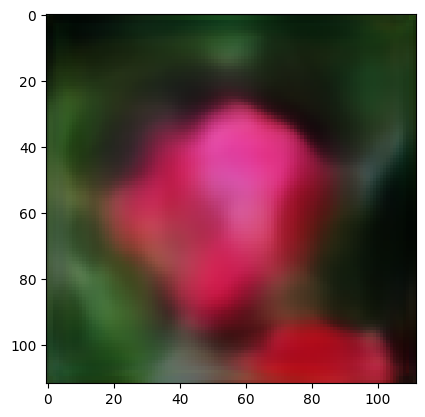

In [4]:
from tensorflow.keras.preprocessing import image
import numpy as np 

def preprocess(img_path):
    img = image.load_img(img_path)
    img_array = image.img_to_array(img)
    image_ = tf.image.resize(img_array, size=SIZE)
    image_ = tf.expand_dims(image_, axis=0)
    image_ = tf.cast(image_, tf.float32) / 255.0 
    return image_

img = preprocess("flower2.jpeg")
print(img.shape)
plt.imshow(np.squeeze(DR_model.predict(img)))
plt.show()


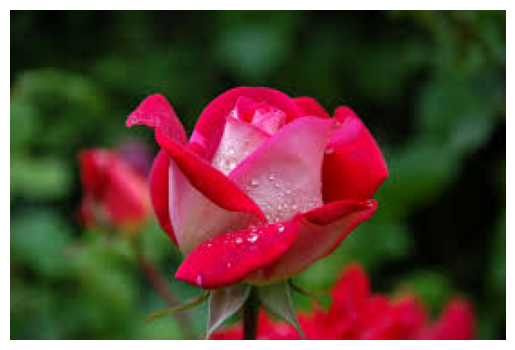

In [5]:
from PIL import Image
image = Image.open("flower2.jpeg")

image_array = np.array(image)

plt.imshow(image_array)
plt.axis('off')  
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


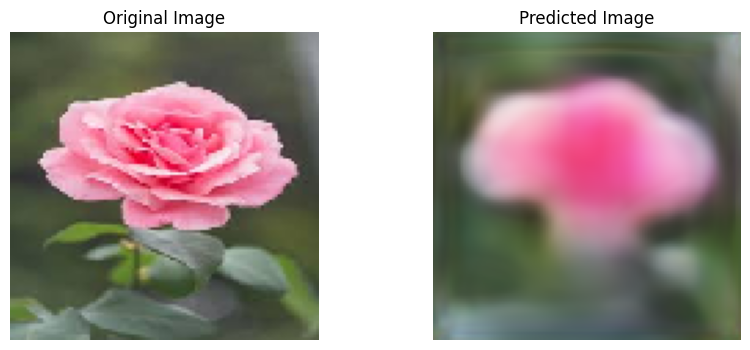

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array, load_img

image_path = "flower.jpeg"
image = load_img(image_path, target_size=(112, 112)) 
image = img_to_array(image)  
image = image / 255.0 
image = np.expand_dims(image, axis=0) 
predicted_image = DR_model.predict(image)
predicted_image = np.squeeze(predicted_image) 
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(np.squeeze(image), cmap='gray')  # Original image
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(predicted_image, cmap='gray')  # Predicted image
plt.title('Predicted Image')
plt.axis('off')

plt.show()
